# Method 2 (DiffBIR) -- Evaluation Notebook

Evaluates both stages of Method 2: Stage 1 alone (`evaluate.py`), and the full Stage 1 + Stage 2 pipeline with classifier-free guidance (`evaluate_stage2.py`). Also includes `regenerate_stage2_grid.py`, which builds a multi-sample qualitative grid from any saved Stage 2 checkpoint without retraining.

**Stage 2 requires unrestricted internet access** (to download the pretrained Stable Diffusion checkpoint from Hugging Face Hub on first run) -- run this on Kaggle with internet enabled, not in a network-sandboxed environment.

## 1. Environment check

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
import torchvision
print("torch", torch.__version__)
print("torchvision", torchvision.__version__)

CUDA available: True
GPU: Tesla T4
torch 2.10.0+cu128
torchvision 0.25.0+cu128


## 2. Install dependencies not preinstalled on Kaggle

In [2]:
!pip install lpips diffusers transformers accelerate --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.6 MB/s eta 0:00:00


## 3. Attach datasets, then define path variables

Attach (Add Data): your VOC2012 clean-photo dataset, your generated masks dataset, and the **output** of your Stage 1 and Stage 2 training notebooks.

Run the `!ls /kaggle/input/` cell below first and correct any paths that don't match.

In [3]:
!ls /kaggle/input/

controlnet-ep2	datasets  notebooks


In [4]:
import torchvision.datasets as tvds
import os

VOC_ROOT = '/kaggle/working/voc_data'
VOC_JPEG_DIR = os.path.join(VOC_ROOT, 'VOCdevkit', 'VOC2012', 'JPEGImages')

if os.path.isdir(VOC_JPEG_DIR) and len(os.listdir(VOC_JPEG_DIR)) > 0:
    print(f'VOC2012 already present at {VOC_JPEG_DIR}, skipping download.')
else:
    os.makedirs(VOC_ROOT, exist_ok=True)
    _ = tvds.VOCDetection(root=VOC_ROOT, year='2012', image_set='train', download=True)

num_images = len([f for f in os.listdir(VOC_JPEG_DIR) if f.lower().endswith('.jpg')])
print(f'VOC2012 ready: {num_images} images at {VOC_JPEG_DIR}')

100%|██████████| 2.00G/2.00G [01:17<00:00, 25.8MB/s]


VOC2012 ready: 17125 images at /kaggle/working/voc_data/VOCdevkit/VOC2012/JPEGImages


In [5]:
import os

  # adjust to however you extract it
MASKS_DIR = '/kaggle/input/datasets/dorast/generated-masks'

DAMAGE_TYPES = ['dirt', 'scratches', 'smut', 'spots']  # adjust if the ls output above shows different names

MASKS_DIRS = [os.path.join(MASKS_DIR, t) for t in DAMAGE_TYPES]

for d in MASKS_DIRS:
    n = len([f for f in os.listdir(d) if f.startswith('mask_')]) if os.path.isdir(d) else 0
    print(f'{d}: {n} masks')

STAGE1_CHECKPOINT = '/kaggle/input/controlnet-ep2/runs/baseline_check/checkpoints/best.pt'
STAGE2_CHECKPOINT = '/kaggle/input/notebooks/dorast/diff-stage-2/runs/stage2_baseline_check/checkpoints/stage2_controlnet_epoch0015.pt'

for path in [STAGE1_CHECKPOINT, STAGE2_CHECKPOINT]:
    print(os.path.exists(path), path)

/kaggle/input/datasets/dorast/generated-masks/dirt: 3000 masks
/kaggle/input/datasets/dorast/generated-masks/scratches: 3000 masks
/kaggle/input/datasets/dorast/generated-masks/smut: 3000 masks
/kaggle/input/datasets/dorast/generated-masks/spots: 3000 masks
True /kaggle/input/controlnet-ep2/runs/baseline_check/checkpoints/best.pt
True /kaggle/input/notebooks/dorast/diff-stage-2/runs/stage2_baseline_check/checkpoints/stage2_controlnet_epoch0015.pt


## 4. Write the model and data dependency files

Shared by both Stage 1 and Stage 2 evaluation, plus Stage 2's own additional files.

In [6]:
import os
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

In [7]:
%%writefile models/__init__.py



Writing models/__init__.py


In [8]:
%%writefile models/blocks.py
"""
Building blocks for the Stage 1 restoration network.

Note the deliberate architectural difference from the VAE scaffold used for
the GAN+latent-translation method: Stage 1 here is a *deterministic*
restoration network with U-Net-style skip connections, not a VAE with a
compressive stochastic bottleneck. That's an intentional choice, not an
oversight -- Stage 1's job is "remove degradation while staying as
faithful as possible to the input," and skip connections are what let fine
detail (edges, texture) bypass the bottleneck entirely rather than being
forced through a compressed latent representation. The original DiffBIR
paper uses SwinIR (a transformer-based restorer) for this stage; a
convolutional U-Net plays the same functional role at a fraction of the
compute, which is a reasonable and defensible scope reduction for a thesis
rather than a full from-scratch SwinIR reproduction.
"""

import torch
import torch.nn as nn


class ConvBlock(nn.Module):
    """Two convs + norm + activation, resolution-preserving. The basic unit
    used at every U-Net stage (encoder, bottleneck, and decoder)."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class DownBlock(nn.Module):
    """ConvBlock followed by a strided-conv downsample. Returns both the
    pre-downsample features (kept as a skip connection) and the
    downsampled output (passed deeper into the encoder)."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.downsample = nn.Conv2d(out_channels, out_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x: torch.Tensor):
        skip = self.conv(x)
        down = self.downsample(skip)
        return down, skip


class UpBlock(nn.Module):
    """Upsamples, concatenates the matching encoder skip connection, then
    fuses with a ConvBlock. This is the actual mechanism that lets Stage 1
    stay faithful to fine input detail rather than smoothing everything
    through the bottleneck."""

    def __init__(self, in_channels: int, skip_channels: int, out_channels: int):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_channels, in_channels, kernel_size=4, stride=2, padding=1)
        self.conv = ConvBlock(in_channels + skip_channels, out_channels)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.upsample(x)
        # Guard against off-by-one size mismatches from odd input dimensions
        if x.shape[-2:] != skip.shape[-2:]:
            x = torch.nn.functional.interpolate(x, size=skip.shape[-2:], mode="nearest")
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


Writing models/blocks.py


In [9]:
%%writefile models/restoration_net.py
"""
Stage 1 restoration network: a convolutional U-Net that maps a damaged
(scratches/smut-composited) photo to a restored one.

This is deliberately simpler than DiffBIR's own Stage 1 (which uses
SwinIR, a much heavier transformer-based restorer trained on a broad,
generic blur/noise/JPEG/downsampling degradation model). Two scope
decisions worth being explicit about in your thesis writeup:

1. Architecture: U-Net instead of SwinIR. Same functional role (faithful,
   detail-preserving degradation removal), far less compute. This is a
   standard, well-understood restoration architecture in its own right
   (used across denoising/inpainting literature), not a shortcut invented
   for this project.

2. Degradation model: trained specifically on YOUR FilmDamageSimulator
   scratches/smut compositing, not DiffBIR's generic blur/noise/JPEG/
   downsampling pipeline. This is actually a *better* fit for your thesis
   question (how well does this restoration paradigm handle these specific
   damage types) than reproducing their generic degradation model would be.
"""

import torch
import torch.nn as nn

from models.blocks import ConvBlock, DownBlock, UpBlock


class RestorationUNet(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 3,
                 base_channels: int = 64, n_downsample: int = 4, max_channels: int = 512):
        super().__init__()

        # Build the channel sequence for each encoder stage, e.g. for
        # base_channels=64, n_downsample=4: [64, 128, 256, 512, 512]
        channels = [min(base_channels * (2 ** i), max_channels) for i in range(n_downsample + 1)]

        self.down_blocks = nn.ModuleList()
        in_ch = in_channels
        for out_ch in channels[:-1]:
            self.down_blocks.append(DownBlock(in_ch, out_ch))
            in_ch = out_ch

        self.bottleneck = nn.Sequential(
            ConvBlock(channels[-2], channels[-1]),
            ConvBlock(channels[-1], channels[-1]),
        )

        self.up_blocks = nn.ModuleList()
        up_in_ch = channels[-1]
        for skip_ch in reversed(channels[:-1]):
            self.up_blocks.append(UpBlock(up_in_ch, skip_ch, skip_ch))
            up_in_ch = skip_ch

        self.final_conv = nn.Sequential(
            nn.Conv2d(channels[0], out_channels, kernel_size=3, padding=1),
            nn.Tanh(),  # output in [-1, 1], matching the dataset's normalization
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        skips = []
        for down in self.down_blocks:
            x, skip = down(x)
            skips.append(skip)

        x = self.bottleneck(x)

        for up, skip in zip(self.up_blocks, reversed(skips)):
            x = up(x, skip)

        return self.final_conv(x)


def restoration_loss(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor = None,
                      l1_weight: float = 1.0, damage_weight: float = 5.0):
    """
    L1 reconstruction loss, matching DiffBIR's own design reasoning for
    this stage: a regression loss here produces a faithful-but-slightly-
    smoothed output, and that's intentional -- Stage 2 (the diffusion
    prior, built separately) is what adds sharp detail back on top of
    this. Don't be tempted to add heavy perceptual/adversarial losses here
    to make Stage 1 alone look sharper; that would blur the separation of
    concerns the two-stage design is built around.

    If `mask` is provided (convention: 1.0 = clean, 0.0 = fully damaged),
    damaged pixels get amplified weight via `damage_weight`. Without this,
    damaged pixels are typically a small fraction of the image, so the
    network can achieve a steadily-improving average loss while barely
    learning to actually repair damage -- the same dilution problem
    observed in Method 3's transformer regression training, which shares
    this dataset and loss structure. damage_weight=5.0 means a fully
    damaged pixel contributes 6x the loss weight of a clean pixel.

    Returns (weighted_loss_for_backprop, plain_unweighted_l1_for_logging).
    """
    per_pixel_l1 = torch.abs(pred - target)
    plain_l1 = per_pixel_l1.mean()

    if mask is None:
        return l1_weight * plain_l1, plain_l1

    weight_map = 1.0 + damage_weight * (1.0 - mask)
    weighted_l1 = (per_pixel_l1 * weight_map).mean()
    return l1_weight * weighted_l1, plain_l1


Writing models/restoration_net.py


In [10]:
%%writefile models/diffusion_stage2.py
"""
Method 2, Stage 2: the frozen Stable Diffusion backbone + the trainable
ControlNet-style conditioning adapter that steers it using Stage 1's
output.

Uses HuggingFace's `diffusers` library directly for the frozen components
(AutoencoderKL, UNet2DConditionModel, CLIP text encoder) and for
ControlNetModel itself, rather than reimplementing any of this from
scratch -- these are large, well-tested public components, and the actual
"method" being recreated here is how they're combined and what gets
trained on top, not the internals of Stable Diffusion itself.

What's frozen vs. trained:
    Frozen:  AutoencoderKL (VAE), UNet2DConditionModel, CLIP text encoder
    Trained: ControlNetModel (initialized from the frozen UNet's encoder
             half via ControlNetModel.from_unet(), then trained from there)

Requires an internet connection to Hugging Face Hub the first time you
run this (to download the pretrained checkpoint) -- this needs to happen
on Kaggle or another environment with unrestricted internet access, not
in a network-sandboxed environment.
"""

import torch
from diffusers import AutoencoderKL, UNet2DConditionModel, ControlNetModel, DDPMScheduler
from transformers import CLIPTextModel, CLIPTokenizer

DEFAULT_MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"
# Note: the older "runwayml/stable-diffusion-v1-5" repo was taken down by
# RunwayML; this is the current official re-upload/mirror. If this ID ever
# moves again, any of the community archival mirrors (search "stable
# diffusion v1.5 huggingface mirror") should work as a drop-in replacement
# -- the checkpoint contents are identical, only the repo location differs.


def load_frozen_sd_components(model_id: str, device: torch.device, dtype=torch.float32):
    """Loads VAE, UNet, text encoder, and tokenizer from a pretrained SD
    checkpoint, freezes all of them (no gradients, eval mode), and returns
    them along with a DDPM noise scheduler matching the checkpoint's
    training configuration."""
    vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae", torch_dtype=dtype).to(device)
    unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet", torch_dtype=dtype).to(device)
    text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder", torch_dtype=dtype).to(device)
    tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
    noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

    for module in (vae, unet, text_encoder):
        module.eval()
        for p in module.parameters():
            p.requires_grad = False

    return vae, unet, text_encoder, tokenizer, noise_scheduler


def build_controlnet(unet: UNet2DConditionModel) -> ControlNetModel:
    """Builds the trainable ControlNet-style adapter, initialized from the
    frozen UNet's own encoder weights (standard ControlNet initialization
    -- starts as a near-copy of part of the frozen network, then diverges
    as it trains). conditioning_channels=3 because the hint we feed it is
    Stage 1's restored output as a plain RGB image, not a pre-encoded
    latent -- ControlNetModel has its own small conv stem that embeds the
    raw image internally."""
    controlnet = ControlNetModel.from_unet(unet, conditioning_channels=3)
    return controlnet


def get_empty_prompt_embedding(text_encoder: CLIPTextModel, tokenizer: CLIPTokenizer, device: torch.device):
    """This project isn't text-conditioned -- there's no prompt to guide
    restoration with -- but UNet2DConditionModel's cross-attention layers
    still expect an encoder_hidden_states tensor of the right shape. The
    standard approach (same one used by unconditional/conditioning-only
    ControlNet applications) is to encode a fixed empty string once and
    reuse that same embedding for every sample."""
    with torch.no_grad():
        tokens = tokenizer([""], padding="max_length", max_length=tokenizer.model_max_length,
                            truncation=True, return_tensors="pt").to(device)
        embedding = text_encoder(tokens.input_ids)[0]
    return embedding


def encode_to_latent(vae: AutoencoderKL, image: torch.Tensor) -> torch.Tensor:
    """Encodes an image tensor (expected in [-1, 1], matching the rest of
    this project's normalization convention) into the VAE's latent space,
    applying the scaling factor the way Stable Diffusion's own training
    pipeline does."""
    with torch.no_grad():
        latent_dist = vae.encode(image).latent_dist
        latent = latent_dist.sample() * vae.config.scaling_factor
    return latent


def decode_from_latent(vae: AutoencoderKL, latent: torch.Tensor) -> torch.Tensor:
    """Inverse of encode_to_latent -- turns a latent back into an image in
    [-1, 1]."""
    with torch.no_grad():
        image = vae.decode(latent / vae.config.scaling_factor).sample
    return image


Writing models/diffusion_stage2.py


In [11]:
%%writefile data/__init__.py



Writing data/__init__.py


In [12]:
%%writefile data/degraded_pair_dataset.py
"""
Dataset for Stage 1 training: pairs of (damaged, clean) images, where the
damage comes from YOUR existing FilmDamageSimulator mask pool (generated
via generate_synthetic_only.py) rather than DiffBIR's generic synthetic
blur/noise/JPEG degradation pipeline.

Masks are composited onto clean images on the fly (mask value 255 = clean,
toward 0 = damaged), so a given clean image can pair with a different
random mask each epoch -- more effective training variety than
pre-generating a fixed set of damaged/clean pairs once.

Three blend_mode options:
  - "screen": damage LIGHTENS toward white. Physically realistic for
    scratches/abrasion, where the print's emulsion is scraped away and
    the lighter paper base shows through.
  - "multiply": damage DARKENS toward black. More appropriate for damage
    that deposits dark material (soot/smut, heavy dirt, mold staining).
  - "mixed" (default): randomly picks screen or multiply PER SAMPLE, with
    probability controlled by white_probability (default 0.8 = 80% white
    scratches, 20% black smut-style damage). This approximates a realistic
    mixture of damage appearances without needing to track which mask
    pixel came from which physical damage type.
"""

import os
import random

from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF


class DegradedPairDataset(Dataset):
    """
    Expects:
        clean_dir/    -- folder of clean photos (e.g. a VOC2012 subset)
        masks_dir     -- one folder path, OR a list of folder paths, each
                          containing grayscale masks from
                          generate_synthetic_only.py (mask_*.png; NOT the
                          binarised_mask_*.png variants -- those are
                          thresholded and lose the soft edges that make
                          compositing look natural).

                          Passing multiple folders lets you keep damage
                          types in physically separate folders (e.g. one
                          for scratches, one for smut) and combine
                          whichever subset you want per run, rather than
                          always drawing from one mixed pool.
    """

    def __init__(self, clean_dir: str, masks_dir, image_size: int = 256, augment: bool = True,
                 blend_mode: str = "screen", white_probability: float = 0.8):
        if blend_mode not in ("screen", "multiply", "mixed"):
            raise ValueError(f"blend_mode must be 'screen', 'multiply', or 'mixed', got '{blend_mode}'")
        if not (0.0 <= white_probability <= 1.0):
            raise ValueError(f"white_probability must be between 0 and 1, got {white_probability}")
        self.clean_dir = clean_dir
        self.masks_dirs = [masks_dir] if isinstance(masks_dir, str) else list(masks_dir)
        self.image_size = image_size
        self.augment = augment
        self.blend_mode = blend_mode
        self.white_probability = white_probability

        valid_ext = (".jpg", ".jpeg", ".png")
        self.clean_files = [f for f in os.listdir(clean_dir) if f.lower().endswith(valid_ext)]

        self.mask_files = []
        for d in self.masks_dirs:
            for f in os.listdir(d):
                if f.lower().endswith(".png") and not f.startswith("binarised_mask"):
                    self.mask_files.append(os.path.join(d, f))

        if len(self.clean_files) == 0:
            raise ValueError(f"No clean images found in {clean_dir}")
        if len(self.mask_files) == 0:
            raise ValueError(f"No usable masks found in {self.masks_dirs} "
                              f"(looking for mask_*.png, excluding binarised_mask_*.png)")

        load_size = int(image_size * 1.12)
        self.clean_resize = T.Resize(load_size)
        self.image_size_final = image_size

    def __len__(self):
        return len(self.clean_files)

    def _load_clean(self, idx):
        path = os.path.join(self.clean_dir, self.clean_files[idx])
        img = Image.open(path).convert("RGB")
        return self.clean_resize(img)

    def _load_random_mask(self):
        path = random.choice(self.mask_files)
        mask = Image.open(path).convert("L")  # single-channel grayscale
        return mask

    def _synchronized_crop_and_flip(self, clean_img, mask_img):
        """Applies the SAME random crop and flip to both the clean image
        and the mask, so the damage stays spatially aligned with the
        content it's composited onto."""
        # Resize mask to match the (already resized) clean image
        mask_img = mask_img.resize(clean_img.size, Image.BILINEAR)

        if self.augment:
            i, j, h, w = T.RandomCrop.get_params(clean_img, output_size=(self.image_size_final, self.image_size_final))
            clean_img = TF.crop(clean_img, i, j, h, w)
            mask_img = TF.crop(mask_img, i, j, h, w)

            if random.random() < 0.5:
                clean_img = TF.hflip(clean_img)
                mask_img = TF.hflip(mask_img)
            # Masks (unlike photo content) are safe to rotate freely --
            # scratches/smut don't have a "correct" orientation the way a
            # photo of a person or building does.
            if random.random() < 0.5:
                angle = random.choice([90, 180, 270])
                mask_img = TF.rotate(mask_img, angle)
        else:
            clean_img = TF.center_crop(clean_img, (self.image_size_final, self.image_size_final))
            mask_img = TF.center_crop(mask_img, (self.image_size_final, self.image_size_final))

        return clean_img, mask_img

    def __getitem__(self, idx):
        try:
            clean_img = self._load_clean(idx)
            mask_img = self._load_random_mask()
        except Exception:
            return self.__getitem__(random.randrange(len(self)))

        clean_img, mask_img = self._synchronized_crop_and_flip(clean_img, mask_img)

        clean_tensor = TF.to_tensor(clean_img)          # [0, 1], shape (3, H, W)
        mask_tensor = TF.to_tensor(mask_img)             # [0, 1], shape (1, H, W)

        # Composite damage onto the clean image. In "mixed" mode, each
        # sample independently rolls screen vs. multiply according to
        # white_probability -- e.g. the default 0.8 means roughly 80% of
        # composited samples get light/white damage (scratches-style) and
        # 20% get dark/black damage (smut-style), rather than one fixed
        # blend applied uniformly to the whole dataset.
        if self.blend_mode == "mixed":
            sample_blend = "screen" if random.random() < self.white_probability else "multiply"
        else:
            sample_blend = self.blend_mode

        if sample_blend == "screen":
            # Lightens toward white at damaged (low-mask) pixels.
            damaged_tensor = 1.0 - (1.0 - clean_tensor) * mask_tensor
        else:  # "multiply"
            # Darkens toward black at damaged (low-mask) pixels.
            damaged_tensor = clean_tensor * mask_tensor

        # Normalize both to [-1, 1] to match the restoration network's Tanh output
        normalize = T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        clean_tensor = normalize(clean_tensor)
        damaged_tensor = normalize(damaged_tensor)

        return {"damaged": damaged_tensor, "clean": clean_tensor, "mask": mask_tensor}


def denormalize(tensor: torch.Tensor) -> torch.Tensor:
    """Inverse of the Normalize(mean=0.5, std=0.5) above, for saving/viewing."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)


Writing data/degraded_pair_dataset.py


## 5. Write the training scripts and evaluation scripts

`train_stage2_diffusion.py` is needed here even though we're not training -- `evaluate_stage2.py` imports its `load_frozen_stage1` helper function from it.

In [13]:
%%writefile train_stage2_diffusion.py
"""
Train Method 2's Stage 2: the ControlNet-style adapter that steers a
frozen pretrained Stable Diffusion model using Stage 1's restored output
as a conditioning signal, adding back realistic detail that Stage 1's
regression loss necessarily smoothed away.

Per training step:
    1. Damaged image -> frozen Stage 1 model -> restored-but-smoothed
       output (this is the "hint")
    2. Clean target image -> frozen VAE -> clean latent
    3. Random noise added to the clean latent at a random timestep
       (standard diffusion training)
    4. ControlNet processes the noisy latent + the Stage 1 hint, producing
       residual signals injected into the frozen UNet's blocks
    5. Frozen UNet predicts the noise that was added; loss = MSE between
       predicted and actual noise
    6. Only the ControlNet's weights are updated

Requires unrestricted internet access to Hugging Face Hub (to download
the pretrained SD checkpoint on first run) -- run this on Kaggle or
similar, not in a network-sandboxed environment.

Usage:
    python train_stage2_diffusion.py \
        --stage1-checkpoint ./runs/stage1_restoration/checkpoints/stage1_epoch0050.pt \
        --clean-dir ./voc_data --masks-dir ./generated_masks \
        --epochs 20 --batch-size 1 --image-size 256 \
        --amp --gradient-checkpointing --out-dir ./runs/stage2_diffusion
"""

import argparse
import os
import time
from datetime import datetime

import torch
from torch.utils.data import DataLoader, RandomSampler
import torchvision.utils as vutils
from tqdm import tqdm

from models.restoration_net import RestorationUNet
from models.diffusion_stage2 import (
    load_frozen_sd_components, build_controlnet, get_empty_prompt_embedding,
    encode_to_latent, decode_from_latent, DEFAULT_MODEL_ID,
)
from data.degraded_pair_dataset import DegradedPairDataset, denormalize


def format_duration(seconds):
    seconds = int(seconds)
    hours, remainder = divmod(seconds, 3600)
    minutes, secs = divmod(remainder, 60)
    if hours:
        return f"{hours}h {minutes}m {secs}s"
    if minutes:
        return f"{minutes}m {secs}s"
    return f"{secs}s"


class Logger:
    def __init__(self, log_path):
        os.makedirs(os.path.dirname(log_path) or ".", exist_ok=True)
        self._file = open(log_path, "a", encoding="utf-8")

    def log(self, msg):
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        line = f"[{timestamp}] {msg}"
        print(line, flush=True)
        self._file.write(line + "\n")
        self._file.flush()

    def close(self):
        self._file.close()


def load_frozen_stage1(checkpoint_path, device):
    """Same architecture-from-checkpoint-args pattern as evaluate.py."""
    ckpt = torch.load(checkpoint_path, map_location=device)
    train_args = ckpt.get("args", {})
    model = RestorationUNet(
        in_channels=3, out_channels=3,
        base_channels=train_args.get("base_channels", 64),
        n_downsample=train_args.get("n_downsample", 4),
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model


@torch.no_grad()
def sample_and_save(unet, controlnet, vae, hint_image, clean_image, empty_embedding,
                     noise_scheduler, num_inference_steps, device, out_path, use_amp=False):
    """Runs a full multi-step diffusion sampling loop conditioned on a
    fixed hint, decodes the result, and saves a
    [Stage-1 hint | Stage-2 output | clean target] comparison grid."""
    controlnet.eval()
    batch_size = hint_image.shape[0]
    latent_h = hint_image.shape[-2] // 8
    latent_w = hint_image.shape[-1] // 8

    latents = torch.randn((batch_size, unet.config.in_channels, latent_h, latent_w), device=device)
    noise_scheduler.set_timesteps(num_inference_steps, device=device)
    latents = latents * noise_scheduler.init_noise_sigma

    for t in noise_scheduler.timesteps:
        latent_model_input = noise_scheduler.scale_model_input(latents, t)

        # Wrapped in the same autocast context as the training loop's
        # identical calls -- without this, sampling ran the frozen/trainable
        # modules in a different precision than training, an inconsistency
        # worth eliminating even where it isn't the direct cause of a crash.
        with torch.amp.autocast(device.type, enabled=use_amp):
            down_res, mid_res = controlnet(
                latent_model_input, t, encoder_hidden_states=empty_embedding,
                controlnet_cond=hint_image, return_dict=False,
            )
            noise_pred = unet(
                latent_model_input, t, encoder_hidden_states=empty_embedding,
                down_block_additional_residuals=down_res, mid_block_additional_residual=mid_res,
            ).sample

        latents = noise_scheduler.step(noise_pred, t, latents).prev_sample

    decoded = decode_from_latent(vae, latents)

    grid = torch.cat([denormalize(hint_image), denormalize(decoded.clamp(-1, 1)), denormalize(clean_image)], dim=0)
    vutils.save_image(grid, out_path, nrow=batch_size)
    controlnet.train()


def main():
    parser = argparse.ArgumentParser(description="Train Method 2's Stage 2 ControlNet-style adapter.")
    parser.add_argument("--stage1-checkpoint", type=str, required=True)
    parser.add_argument("--clean-dir", type=str, required=True)
    parser.add_argument("--masks-dir", type=str, required=True, nargs="+")
    parser.add_argument("--blend-mode", type=str, choices=["screen", "multiply", "mixed"], default="screen")
    parser.add_argument("--model-id", type=str, default=DEFAULT_MODEL_ID,
                         help="Hugging Face Hub ID of the pretrained Stable Diffusion checkpoint")
    parser.add_argument("--out-dir", type=str, default="./runs/stage2_diffusion")
    parser.add_argument("--image-size", type=int, default=128,
                         help="must be divisible by 8 (the VAE's downsampling factor)")
    parser.add_argument("--batch-size", type=int, default=1,
                         help="Stage 2 is far heavier than Stage 1 -- start at 1 and only raise this "
                              "if you have headroom left after --gradient-checkpointing and --amp")
    parser.add_argument("--epochs", type=int, default=20)
    parser.add_argument("--lr", type=float, default=1e-5,
                         help="ControlNet training typically uses a smaller LR than training from scratch")
    parser.add_argument("--num-inference-steps", type=int, default=20,
                         help="denoising steps used for sample-grid visualization during training "
                              "(fewer = faster preview, not used for final quality)")
    parser.add_argument("--gradient-checkpointing", action="store_true",
                         help="enables gradient checkpointing on the frozen UNet and the trainable "
                              "ControlNet -- strongly recommended, this stage is memory-heavy")
    parser.add_argument("--num-workers", type=int, default=2)
    parser.add_argument("--save-every", type=int, default=1)
    parser.add_argument("--sample-every", type=int, default=200)
    parser.add_argument("--steps-per-epoch", type=int, default=None)
    parser.add_argument("--log-every", type=int, default=10)
    parser.add_argument("--resume", type=str, default=None)
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    parser.add_argument("--amp", action="store_true")
    args = parser.parse_args()

    if args.image_size % 8 != 0:
        raise ValueError(f"--image-size must be divisible by 8 (VAE downsampling factor), got {args.image_size}")

    os.makedirs(args.out_dir, exist_ok=True)
    checkpoints_dir = os.path.join(args.out_dir, "checkpoints")
    samples_dir = os.path.join(args.out_dir, "samples")
    os.makedirs(checkpoints_dir, exist_ok=True)
    os.makedirs(samples_dir, exist_ok=True)

    logger = Logger(os.path.join(args.out_dir, "train_log.txt"))
    log = logger.log

    device = torch.device(args.device)
    log(f"Using device: {device}")
    if device.type == "cuda":
        log(f"  GPU: {torch.cuda.get_device_name(device)}")

    log(f"Loading frozen Stage 1 checkpoint from {args.stage1_checkpoint}")
    stage1_model = load_frozen_stage1(args.stage1_checkpoint, device)

    log(f"Loading frozen Stable Diffusion components from '{args.model_id}' "
        f"(requires internet access to Hugging Face Hub)...")
    vae, unet, text_encoder, tokenizer, noise_scheduler = load_frozen_sd_components(args.model_id, device)
    log("Frozen SD components loaded and frozen (VAE, UNet, text encoder).")

    log("Building trainable ControlNet adapter from the frozen UNet...")
    controlnet = build_controlnet(unet).to(device)

    if args.gradient_checkpointing:
        unet.enable_gradient_checkpointing()
        controlnet.enable_gradient_checkpointing()
        log("Gradient checkpointing enabled on UNet and ControlNet.")

    empty_embedding = get_empty_prompt_embedding(text_encoder, tokenizer, device)
    log(f"Empty-prompt text embedding ready, shape={tuple(empty_embedding.shape)}")

    log("Building dataset...")
    dataset = DegradedPairDataset(args.clean_dir, args.masks_dir, image_size=args.image_size,
                                   augment=True, blend_mode=args.blend_mode)
    log(f"Loaded {len(dataset)} clean images, {len(dataset.mask_files)} masks")

    if args.steps_per_epoch:
        num_samples = args.steps_per_epoch * args.batch_size
        sampler = RandomSampler(dataset, replacement=True, num_samples=num_samples)
        dataloader = DataLoader(dataset, batch_size=args.batch_size, sampler=sampler,
                                 num_workers=args.num_workers, drop_last=True, pin_memory=(device.type == "cuda"))
        log(f"Using --steps-per-epoch {args.steps_per_epoch}: {num_samples} images/epoch")
    else:
        dataloader = DataLoader(dataset, batch_size=args.batch_size, shuffle=True,
                                 num_workers=args.num_workers, drop_last=True, pin_memory=(device.type == "cuda"))

    fixed_batch = next(iter(dataloader))

    optimizer = torch.optim.AdamW(controlnet.parameters(), lr=args.lr)
    use_amp = args.amp and device.type == "cuda"
    scaler = torch.amp.GradScaler(device.type, enabled=use_amp)

    start_epoch = 1
    global_step = 0
    if args.resume:
        log(f"Resuming ControlNet weights from {args.resume}")
        ckpt = torch.load(args.resume, map_location=device)
        controlnet.load_state_dict(ckpt["controlnet_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        if "scaler_state_dict" in ckpt:
            scaler.load_state_dict(ckpt["scaler_state_dict"])
        start_epoch = ckpt["epoch"] + 1
        global_step = ckpt.get("global_step", 0)

    num_trainable = sum(p.numel() for p in controlnet.parameters())
    log(f"ControlNet has {num_trainable:,} trainable parameters (UNet/VAE/text encoder frozen)")
    log(f"Starting training: epochs {start_epoch}-{args.epochs}")

    start_time = time.time()

    for epoch in range(start_epoch, args.epochs + 1):
        epoch_start = time.time()
        running_loss = 0.0

        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}/{args.epochs}", unit="batch", leave=False)
        batch_end_time = time.time()

        for batch in progress_bar:
            data_time = time.time() - batch_end_time
            compute_start = time.time()

            damaged = batch["damaged"].to(device, non_blocking=True)
            clean = batch["clean"].to(device, non_blocking=True)

            with torch.no_grad():
                hint = stage1_model(damaged).clamp(-1, 1)

            clean_latent = encode_to_latent(vae, clean)
            noise = torch.randn_like(clean_latent)
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                                       (clean_latent.shape[0],), device=device).long()
            noisy_latent = noise_scheduler.add_noise(clean_latent, noise, timesteps)

            batch_embedding = empty_embedding.expand(clean_latent.shape[0], -1, -1)

            optimizer.zero_grad()

            with torch.amp.autocast(device.type, enabled=use_amp):
                down_res, mid_res = controlnet(
                    noisy_latent, timesteps, encoder_hidden_states=batch_embedding,
                    controlnet_cond=hint, return_dict=False,
                )
                noise_pred = unet(
                    noisy_latent, timesteps, encoder_hidden_states=batch_embedding,
                    down_block_additional_residuals=down_res, mid_block_additional_residual=mid_res,
                ).sample

                loss = torch.nn.functional.mse_loss(noise_pred, noise)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            if device.type == "cuda":
                torch.cuda.synchronize()
            compute_time = time.time() - compute_start

            running_loss += loss.item()
            global_step += 1

            progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

            if args.log_every and global_step % args.log_every == 0:
                log(f"  step {global_step}: loss={loss.item():.4f} "
                    f"data_time={data_time:.3f}s compute_time={compute_time:.3f}s")

            if global_step % args.sample_every == 0:
                sample_path = os.path.join(samples_dir, f"step_{global_step:07d}.png")
                # Cap at args.batch_size, not a hardcoded 2 -- a fixed sample
                # count that can exceed the actual training batch size caused
                # a real shape-mismatch crash (confirmed against the real
                # pretrained checkpoint, since --batch-size 1 training
                # worked fine but sampling was hardcoded to batch-size 2).
                sample_n = min(2, args.batch_size)
                fixed_damaged = fixed_batch["damaged"][:sample_n].to(device)
                fixed_clean = fixed_batch["clean"][:sample_n].to(device)
                with torch.no_grad():
                    fixed_hint = stage1_model(fixed_damaged).clamp(-1, 1)
                fixed_embedding = empty_embedding.expand(sample_n, -1, -1)
                sample_and_save(unet, controlnet, vae, fixed_hint, fixed_clean, fixed_embedding,
                                 noise_scheduler, args.num_inference_steps, device, sample_path,
                                 use_amp=use_amp)
                log(f"  Saved sample grid: {sample_path}")

            batch_end_time = time.time()

        n_batches = len(dataloader)
        elapsed = time.time() - start_time
        log(f"[Epoch {epoch}/{args.epochs}] loss={running_loss / n_batches:.4f} "
            f"epoch_time={format_duration(time.time() - epoch_start)} "
            f"total_elapsed={format_duration(elapsed)}")

        if epoch % args.save_every == 0 or epoch == args.epochs:
            ckpt_path = os.path.join(checkpoints_dir, f"stage2_controlnet_epoch{epoch:04d}.pt")
            torch.save({
                "epoch": epoch, "global_step": global_step,
                "controlnet_state_dict": controlnet.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scaler_state_dict": scaler.state_dict(),
                "args": vars(args),
            }, ckpt_path)
            log(f"  Saved checkpoint: {ckpt_path} (ControlNet weights only -- "
                f"frozen VAE/UNet/text encoder are not re-saved, re-download via --model-id instead)")

    log(f"Training complete. Total time: {format_duration(time.time() - start_time)}")
    logger.close()


if __name__ == "__main__":
    main()


Writing train_stage2_diffusion.py


In [14]:
%%writefile evaluate.py
"""
Evaluate a trained Stage 1 restoration checkpoint: computes PSNR, SSIM,
and LPIPS between (a) damaged vs. clean and (b) restored vs. clean, so
you can see the actual improvement the model provides, not just eyeball
sample grids.

LPIPS (Learned Perceptual Image Patch Similarity) uses a pretrained
network's internal features to judge perceptual similarity, rather than
comparing raw pixel values the way PSNR/SSIM do -- lower is better here,
unlike PSNR/SSIM. It's included specifically because pure-regression
methods like this one tend to score well on PSNR/SSIM (they directly
optimize for pixel accuracy) while looking blurrier than adversarial or
diffusion-based methods to LPIPS, which better reflects that. Comparing
both metric families side by side is more informative than either alone
for a cross-method thesis comparison.

Reconstructs the model architecture from the checkpoint's saved args
(base_channels, n_downsample) automatically -- no need to re-specify them
and risk a mismatch.

Note: for a real baseline sanity check, evaluating on images the model saw
during training is fine (you're just confirming the pipeline/model works).
For your FINAL thesis comparison across all three restoration methods, use
a held-out clean-image set that was never used in ANY training stage --
see the pre-training checklist from earlier in this project.

Usage:
    python evaluate.py --checkpoint ./runs/baseline_check/checkpoints/stage1_epoch0008.pt \
        --clean-dir ./voc_subset_100/images --masks-dir ./generated_masks \
        --num-samples 20 --out-dir ./eval_results
"""

import argparse
import os

import numpy as np
import torch
import lpips
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torchvision.utils as vutils

from models.restoration_net import RestorationUNet
from data.degraded_pair_dataset import DegradedPairDataset, denormalize


def tensor_to_numpy_image(tensor: torch.Tensor) -> np.ndarray:
    """(C, H, W) tensor in [0, 1] -> (H, W, C) numpy array in [0, 255] uint8."""
    arr = tensor.clamp(0, 1).mul(255).byte().permute(1, 2, 0).cpu().numpy()
    return arr


def main():
    parser = argparse.ArgumentParser(description="Evaluate a Stage 1 checkpoint with PSNR/SSIM.")
    parser.add_argument("--checkpoint", type=str, required=True)
    parser.add_argument("--clean-dir", type=str, required=True)
    parser.add_argument("--masks-dir", type=str, required=True, nargs="+",
                         help="one or more mask folders; pass multiple to combine damage types kept "
                              "in separate folders, e.g. --masks-dir ./data/masks/scratches ./data/masks/smut")
    parser.add_argument("--num-samples", type=int, default=20,
                         help="how many random (clean, mask) pairs to evaluate on")
    parser.add_argument("--image-size", type=int, default=None,
                         help="defaults to the image size the checkpoint was trained with")
    parser.add_argument("--out-dir", type=str, default="./eval_results")
    parser.add_argument("--seed", type=int, default=123)
    parser.add_argument("--lpips-net", type=str, choices=["alex", "vgg", "squeeze"], default="alex",
                         help="backbone network for LPIPS perceptual distance; 'alex' is the standard "
                              "default (fastest, most commonly reported in papers)")
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    args = parser.parse_args()

    os.makedirs(args.out_dir, exist_ok=True)
    device = torch.device(args.device)

    print(f"Loading checkpoint: {args.checkpoint}")
    ckpt = torch.load(args.checkpoint, map_location=device)
    train_args = ckpt.get("args", {})

    image_size = args.image_size or train_args.get("image_size", 256)
    base_channels = train_args.get("base_channels", 64)
    n_downsample = train_args.get("n_downsample", 4)
    blend_mode = train_args.get("blend_mode", "screen")

    print(f"  Reconstructed from checkpoint: image_size={image_size}, base_channels={base_channels}, "
          f"n_downsample={n_downsample}, blend_mode={blend_mode}")
    print(f"  Checkpoint was saved at epoch {ckpt.get('epoch', '?')}, step {ckpt.get('global_step', '?')}")

    model = RestorationUNet(in_channels=3, out_channels=3, base_channels=base_channels,
                             n_downsample=n_downsample).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    print(f"Loading LPIPS ({args.lpips_net}) perceptual similarity model...")
    lpips_fn = lpips.LPIPS(net=args.lpips_net).to(device)
    lpips_fn.eval()

    torch.manual_seed(args.seed)
    dataset = DegradedPairDataset(args.clean_dir, args.masks_dir, image_size=image_size,
                                   augment=False, blend_mode=blend_mode)
    num_samples = min(args.num_samples, len(dataset))
    indices = torch.randperm(len(dataset))[:num_samples].tolist()
    print(f"Evaluating on {num_samples} samples (seed={args.seed})")

    damaged_psnrs, damaged_ssims, damaged_lpips = [], [], []
    restored_psnrs, restored_ssims, restored_lpips = [], [], []

    comparison_rows = []

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            damaged = sample["damaged"].unsqueeze(0).to(device)
            clean = sample["clean"].unsqueeze(0).to(device)

            restored = model(damaged)

            damaged_np = tensor_to_numpy_image(denormalize(damaged[0]))
            clean_np = tensor_to_numpy_image(denormalize(clean[0]))
            restored_np = tensor_to_numpy_image(denormalize(restored[0]))

            d_psnr = peak_signal_noise_ratio(clean_np, damaged_np, data_range=255)
            d_ssim = structural_similarity(clean_np, damaged_np, channel_axis=2, data_range=255)
            r_psnr = peak_signal_noise_ratio(clean_np, restored_np, data_range=255)
            r_ssim = structural_similarity(clean_np, restored_np, channel_axis=2, data_range=255)

            # LPIPS expects [-1, 1]-range tensors -- damaged/clean/restored are
            # already in that range (denormalize() above is only used for the
            # PSNR/SSIM numpy conversion), so feed the raw tensors directly.
            d_lpips = lpips_fn(damaged, clean).item()
            r_lpips = lpips_fn(restored, clean).item()

            damaged_psnrs.append(d_psnr)
            damaged_ssims.append(d_ssim)
            damaged_lpips.append(d_lpips)
            restored_psnrs.append(r_psnr)
            restored_ssims.append(r_ssim)
            restored_lpips.append(r_lpips)

            if i < 6:  # keep a handful for a visual comparison grid
                comparison_rows.append((denormalize(damaged[0]).cpu(),
                                         denormalize(restored[0]).cpu(),
                                         denormalize(clean[0]).cpu()))

    def summarize(name, values):
        arr = np.array(values)
        print(f"  {name}: mean={arr.mean():.3f}  std={arr.std():.3f}  min={arr.min():.3f}  max={arr.max():.3f}")

    print("\n=== Damaged vs. Clean (baseline, no restoration) ===")
    summarize("PSNR (dB, higher=better)", damaged_psnrs)
    summarize("SSIM (0-1, higher=better)", damaged_ssims)
    summarize("LPIPS (0-1ish, lower=better)", damaged_lpips)

    print("\n=== Restored vs. Clean (model output) ===")
    summarize("PSNR (dB, higher=better)", restored_psnrs)
    summarize("SSIM (0-1, higher=better)", restored_ssims)
    summarize("LPIPS (0-1ish, lower=better)", restored_lpips)

    psnr_gain = np.mean(restored_psnrs) - np.mean(damaged_psnrs)
    ssim_gain = np.mean(restored_ssims) - np.mean(damaged_ssims)
    lpips_gain = np.mean(damaged_lpips) - np.mean(restored_lpips)  # positive = improvement (LPIPS went down)
    print(f"\n=== Improvement from restoration ===")
    print(f"  PSNR gain: {psnr_gain:+.3f} dB")
    print(f"  SSIM gain: {ssim_gain:+.3f}")
    print(f"  LPIPS gain: {lpips_gain:+.3f} (positive = perceptually closer to clean after restoration)")
    if psnr_gain <= 0:
        print("  Note: non-positive PSNR gain means the model isn't yet improving over doing nothing -- "
              "expected for a short baseline check, but worth watching on longer runs.")

    # Save per-sample results to CSV
    csv_path = os.path.join(args.out_dir, "metrics.csv")
    with open(csv_path, "w") as f:
        f.write("sample_index,damaged_psnr,damaged_ssim,damaged_lpips,restored_psnr,restored_ssim,restored_lpips\n")
        for idx, dp, ds, dl, rp, rs, rl in zip(indices, damaged_psnrs, damaged_ssims, damaged_lpips,
                                                 restored_psnrs, restored_ssims, restored_lpips):
            f.write(f"{idx},{dp:.4f},{ds:.4f},{dl:.4f},{rp:.4f},{rs:.4f},{rl:.4f}\n")
    print(f"\nPer-sample metrics saved to {csv_path}")

    # Save a visual comparison grid
    if comparison_rows:
        damaged_imgs = torch.stack([r[0] for r in comparison_rows])
        restored_imgs = torch.stack([r[1] for r in comparison_rows])
        clean_imgs = torch.stack([r[2] for r in comparison_rows])
        grid = torch.cat([damaged_imgs, restored_imgs, clean_imgs], dim=0)
        grid_path = os.path.join(args.out_dir, "comparison_grid.png")
        vutils.save_image(grid, grid_path, nrow=len(comparison_rows))
        print(f"Visual comparison grid saved to {grid_path}")


if __name__ == "__main__":
    main()


Writing evaluate.py


In [15]:
%%writefile evaluate_stage2.py
"""
Evaluate Method 2's full two-stage pipeline: frozen Stage 1 regression
network -> frozen Stable Diffusion + trained ControlNet-style adapter
(Stage 2), via the actual multi-step denoising sampling loop.

Unlike train_stage2_diffusion.py's periodic sample grids (qualitative,
saved during training), this computes real PSNR/SSIM/LPIPS numbers on a
held-out set -- the same evaluation pattern as your other three
evaluate.py scripts, for direct comparability in your results chapter.

Reports THREE levels, not just one, since that's genuinely informative
for your thesis rather than just convenient:
    1. Damaged vs. clean       -- the do-nothing baseline
    2. Stage 1 only vs. clean  -- what plain regression achieves alone
    3. Stage 1+2 vs. clean     -- what the diffusion refinement adds on top

Comparing (2) and (3) directly answers "how much does the diffusion prior
actually help over regression alone" -- the same ablation question raised
earlier when discussing why Method 3 (transformer regression) and Method
2's Stage 1 share the same underlying paradigm.

Requires unrestricted internet access to Hugging Face Hub on first run
(to download the pretrained SD checkpoint) -- run this on Kaggle or
similar, not a network-sandboxed environment.

Multi-step sampling is slow per image (many denoising steps, not one
forward pass) -- expect this to take meaningfully longer than your other
three evaluate.py scripts on the same --num-samples.

Usage:
    python evaluate_stage2.py \
        --stage1-checkpoint ./runs/stage1_restoration/checkpoints/<latest>.pt \
        --controlnet-checkpoint ./runs/stage2_diffusion/checkpoints/<latest>.pt \
        --clean-dir ./data/voc2012/... --masks-dir ./data/generated_masks/scratches ./data/generated_masks/smut \
        --num-samples 50 --num-inference-steps 20 --out-dir ./eval_results_stage2
"""

import argparse
import os

import numpy as np
import cv2
import torch
import lpips
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torchvision.utils as vutils

from models.diffusion_stage2 import (
    load_frozen_sd_components, build_controlnet, get_empty_prompt_embedding,
    decode_from_latent, DEFAULT_MODEL_ID,
)
from train_stage2_diffusion import load_frozen_stage1
from data.degraded_pair_dataset import DegradedPairDataset, denormalize

def transfer_color(source_rgb, target_rgb):
    src_lab = cv2.cvtColor(source_rgb, cv2.COLOR_RGB2LAB)
    tgt_lab = cv2.cvtColor(target_rgb, cv2.COLOR_RGB2LAB)
    tgt_lab[:, :, 1:] = src_lab[:, :, 1:]
    return cv2.cvtColor(tgt_lab, cv2.COLOR_LAB2RGB)


def tensor_to_numpy_image(tensor: torch.Tensor) -> np.ndarray:
    arr = tensor.clamp(0, 1).mul(255).byte().permute(1, 2, 0).cpu().numpy()
    return arr


@torch.no_grad()
def run_sampling(unet, controlnet, vae, hint_image, empty_embedding, noise_scheduler,
                  num_inference_steps, device, guidance_scale=7.5):
    """Same multi-step denoising loop as train_stage2_diffusion.py's
    sample_and_save(), extracted here so it can be reused for a single
    sample at a time during evaluation. Uses classifier-free guidance
    (guidance_scale) to strengthen conditioning on the Stage 1 hint --
    without it, output tends toward desaturated, washed-out colors.
    Empirically, guidance_scale needs to be much lower than the standard
    SD default (7.5) when the ControlNet is still early in training --
    with a weak/noisy conditioning signal, a high guidance_scale amplifies
    that noise rather than genuine signal. Try 1.5-2.5 for an
    early-training ControlNet; raise it once the ControlNet is trained
    further and the conditioned/unconditional predictions diverge more
    meaningfully."""
    batch_size = hint_image.shape[0]
    latent_h = hint_image.shape[-2] // 8
    latent_w = hint_image.shape[-1] // 8

    latents = torch.randn((batch_size, unet.config.in_channels, latent_h, latent_w), device=device)
    noise_scheduler.set_timesteps(num_inference_steps, device=device)
    latents = latents * noise_scheduler.init_noise_sigma

    for t in noise_scheduler.timesteps:
        latent_model_input = noise_scheduler.scale_model_input(latents, t)

        down_res, mid_res = controlnet(
            latent_model_input, t, encoder_hidden_states=empty_embedding,
            controlnet_cond=hint_image, return_dict=False,
        )
        noise_pred_cond = unet(
            latent_model_input, t, encoder_hidden_states=empty_embedding,
            down_block_additional_residuals=down_res, mid_block_additional_residual=mid_res,
        ).sample

        # Unconditional pass -- same UNet call, but without ControlNet's
        # residuals, so the model has no information about the hint image.
        noise_pred_uncond = unet(
            latent_model_input, t, encoder_hidden_states=empty_embedding,
        ).sample

        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)
        latents = noise_scheduler.step(noise_pred, t, latents).prev_sample

    return decode_from_latent(vae, latents).clamp(-1, 1)


def main():
    parser = argparse.ArgumentParser(description="Evaluate Method 2's full Stage 1 + Stage 2 pipeline.")
    parser.add_argument("--stage1-checkpoint", type=str, required=True)
    parser.add_argument("--controlnet-checkpoint", type=str, required=True)
    parser.add_argument("--model-id", type=str, default=DEFAULT_MODEL_ID,
                         help="Hugging Face Hub ID of the pretrained Stable Diffusion checkpoint")
    parser.add_argument("--clean-dir", type=str, required=True)
    parser.add_argument("--masks-dir", type=str, required=True, nargs="+")
    parser.add_argument("--blend-mode", type=str, choices=["screen", "multiply"], default="screen")
    parser.add_argument("--image-size", type=int, default=128,
                         help="must be divisible by 8 (the VAE's downsampling factor)")
    parser.add_argument("--num-samples", type=int, default=50)
    parser.add_argument("--num-inference-steps", type=int, default=20)
    parser.add_argument("--guidance-scale", type=float, default=7.5,
                         help="classifier-free guidance scale; higher values follow the Stage 1 "
                              "hint more strongly. 1.0 disables guidance. Try lower values "
                              "(1.5-2.5) for an early-training ControlNet checkpoint.")
    parser.add_argument("--out-dir", type=str, default="./eval_results_stage2")
    parser.add_argument("--seed", type=int, default=123)
    parser.add_argument("--lpips-net", type=str, choices=["alex", "vgg", "squeeze"], default="alex")
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    args = parser.parse_args()

    if args.image_size % 8 != 0:
        raise ValueError(f"--image-size must be divisible by 8, got {args.image_size}")

    os.makedirs(args.out_dir, exist_ok=True)
    device = torch.device(args.device)

    print(f"Loading frozen Stage 1 from {args.stage1_checkpoint}")
    stage1_model = load_frozen_stage1(args.stage1_checkpoint, device)

    print(f"Loading frozen Stable Diffusion components from '{args.model_id}' "
          f"(requires internet access to Hugging Face Hub)...")
    vae, unet, text_encoder, tokenizer, noise_scheduler = load_frozen_sd_components(args.model_id, device)

    print(f"Building ControlNet and loading trained weights from {args.controlnet_checkpoint}")
    controlnet = build_controlnet(unet).to(device)
    ckpt = torch.load(args.controlnet_checkpoint, map_location=device)
    controlnet.load_state_dict(ckpt["controlnet_state_dict"])
    controlnet.eval()
    print(f"  Checkpoint was saved at epoch {ckpt.get('epoch', '?')}, step {ckpt.get('global_step', '?')}")

    empty_embedding = get_empty_prompt_embedding(text_encoder, tokenizer, device)

    print(f"Loading LPIPS ({args.lpips_net}) perceptual similarity model...")
    lpips_fn = lpips.LPIPS(net=args.lpips_net).to(device)
    lpips_fn.eval()

    torch.manual_seed(args.seed)
    dataset = DegradedPairDataset(args.clean_dir, args.masks_dir, image_size=args.image_size,
                                   augment=False, blend_mode=args.blend_mode)
    num_samples = min(args.num_samples, len(dataset))
    indices = torch.randperm(len(dataset))[:num_samples].tolist()
    print(f"Evaluating on {num_samples} samples (seed={args.seed}, {args.num_inference_steps} "
          f"denoising steps per sample -- this will take a while)")

    metrics = {level: {"psnr": [], "ssim": [], "lpips": []} for level in ("damaged", "stage1", "stage1_stage2")}
    comparison_rows = []

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            damaged = sample["damaged"].unsqueeze(0).to(device)
            clean = sample["clean"].unsqueeze(0).to(device)

            hint = stage1_model(damaged).clamp(-1, 1)
            embedding = empty_embedding.expand(1, -1, -1)
            restored = run_sampling(unet, controlnet, vae, hint, embedding, noise_scheduler,
                                     args.num_inference_steps, device, guidance_scale=args.guidance_scale)

            clean_np = tensor_to_numpy_image(denormalize(clean[0]))
            for level, output in (("damaged", damaged), ("stage1", hint), ("stage1_stage2", restored)):
                output_np = tensor_to_numpy_image(denormalize(output[0]))
                metrics[level]["psnr"].append(peak_signal_noise_ratio(clean_np, output_np, data_range=255))
                metrics[level]["ssim"].append(structural_similarity(clean_np, output_np, channel_axis=2, data_range=255))
                metrics[level]["lpips"].append(lpips_fn(output, clean).item())

            print(f"  [{i+1}/{num_samples}] done")

            if i < 6:
                comparison_rows.append((denormalize(damaged[0]).cpu(), denormalize(hint[0]).cpu(),
                                         denormalize(restored[0]).cpu(), denormalize(clean[0]).cpu()))

    def summarize(name, values):
        arr = np.array(values)
        print(f"    {name}: mean={arr.mean():.3f}  std={arr.std():.3f}")

    for level, label in (("damaged", "Damaged (no restoration)"),
                          ("stage1", "Stage 1 only (regression)"),
                          ("stage1_stage2", "Stage 1 + Stage 2 (full pipeline)")):
        print(f"\n=== {label} vs. Clean ===")
        summarize("PSNR (dB, higher=better)", metrics[level]["psnr"])
        summarize("SSIM (0-1, higher=better)", metrics[level]["ssim"])
        summarize("LPIPS (0-1ish, lower=better)", metrics[level]["lpips"])

    stage2_psnr_delta = np.mean(metrics["stage1_stage2"]["psnr"]) - np.mean(metrics["stage1"]["psnr"])
    stage2_lpips_delta = np.mean(metrics["stage1"]["lpips"]) - np.mean(metrics["stage1_stage2"]["lpips"])
    print(f"\n=== What Stage 2 adds on top of Stage 1 alone ===")
    print(f"  PSNR change: {stage2_psnr_delta:+.3f} dB")
    print(f"  LPIPS change: {stage2_lpips_delta:+.3f} (positive = perceptually closer to clean)")
    print("  Note: it's common and expected for diffusion refinement to trade some PSNR for "
          "better LPIPS -- it adds plausible detail that may not exactly match ground truth pixels, "
          "but looks more realistic. Both directions are worth reporting, not just PSNR alone.")

    csv_path = os.path.join(args.out_dir, "metrics.csv")
    with open(csv_path, "w") as f:
        f.write("sample_index,damaged_psnr,damaged_ssim,damaged_lpips,"
                "stage1_psnr,stage1_ssim,stage1_lpips,"
                "stage1_stage2_psnr,stage1_stage2_ssim,stage1_stage2_lpips\n")
        for row_i, idx in enumerate(indices):
            f.write(f"{idx},"
                    f"{metrics['damaged']['psnr'][row_i]:.4f},{metrics['damaged']['ssim'][row_i]:.4f},{metrics['damaged']['lpips'][row_i]:.4f},"
                    f"{metrics['stage1']['psnr'][row_i]:.4f},{metrics['stage1']['ssim'][row_i]:.4f},{metrics['stage1']['lpips'][row_i]:.4f},"
                    f"{metrics['stage1_stage2']['psnr'][row_i]:.4f},{metrics['stage1_stage2']['ssim'][row_i]:.4f},{metrics['stage1_stage2']['lpips'][row_i]:.4f}\n")
    print(f"\nPer-sample metrics saved to {csv_path}")

    if comparison_rows:
        damaged_imgs = torch.stack([r[0] for r in comparison_rows])
        stage1_imgs = torch.stack([r[1] for r in comparison_rows])
        stage2_imgs = torch.stack([r[2] for r in comparison_rows])
        clean_imgs = torch.stack([r[3] for r in comparison_rows])
        grid = torch.cat([damaged_imgs, stage1_imgs, stage2_imgs, clean_imgs], dim=0)
        grid_path = os.path.join(args.out_dir, "comparison_grid.png")
        vutils.save_image(grid, grid_path, nrow=len(comparison_rows))
        print(f"Visual comparison grid saved to {grid_path} "
              f"(rows: damaged | stage1 only | stage1+stage2 | clean)")


if __name__ == "__main__":
    main()


Writing evaluate_stage2.py


In [16]:
%%writefile regenerate_stage2_grid.py
"""
Regenerates a multi-sample [damaged | Stage 1 hint | Stage 2 output | clean
target] comparison grid from an already-saved Stage 2 checkpoint -- no
retraining needed. Unlike train_stage2_diffusion.py's periodic sample grids
(which only ever show whatever the CURRENT mini-batch happened to be,
typically just one sample given Stage 2's small batch size), this loads a
FIXED set of several distinct samples, the same way Stage 1's fixed_batch
works.

Uses classifier-free guidance (--guidance-scale) during sampling, which
train_stage2_diffusion.py's own sample_and_save() does not -- without it,
output tends toward desaturated, washed-out colors relative to the clean
target, since the model has no amplified signal steering it away from a
generic, unconditional denoising trajectory.

Also applies post-hoc color correction: transfers Stage 1's color
statistics onto Stage 2's output (DiffBIR's own ablation shows vanilla
ControlNet causes color shifts from pixel-space conditioning).

Usage:
    python regenerate_stage2_grid.py \
        --stage1-checkpoint ./runs/stage1_restoration/checkpoints/best.pt \
        --controlnet-checkpoint ./runs/stage2_diffusion/checkpoints/stage2_controlnet_epoch0002.pt \
        --clean-dir ./data/voc2012/... \
        --masks-dir ./data/generated_masks/scratches ./data/generated_masks/smut \
        --num-samples 6 --num-inference-steps 20 --guidance-scale 7.5 \
        --out-path ./stage2_regenerated_grid.png
"""

import argparse

import numpy as np
import cv2
import torch
import torchvision.utils as vutils

from models.diffusion_stage2 import (
    load_frozen_sd_components, build_controlnet, get_empty_prompt_embedding,
    decode_from_latent, DEFAULT_MODEL_ID,
)
from train_stage2_diffusion import load_frozen_stage1
from data.degraded_pair_dataset import DegradedPairDataset, denormalize


def transfer_color(source_rgb, target_rgb):
    src_lab = cv2.cvtColor(source_rgb, cv2.COLOR_RGB2LAB)
    tgt_lab = cv2.cvtColor(target_rgb, cv2.COLOR_RGB2LAB)
    tgt_lab[:, :, 1:] = src_lab[:, :, 1:]
    return cv2.cvtColor(tgt_lab, cv2.COLOR_LAB2RGB)


def tensor_to_numpy_image(tensor: torch.Tensor) -> np.ndarray:
    arr = tensor.clamp(0, 1).mul(255).byte().permute(1, 2, 0).cpu().numpy()
    return arr


@torch.no_grad()
def run_sampling(unet, controlnet, vae, hint_image, empty_embedding, noise_scheduler,
                  num_inference_steps, device, guidance_scale=7.5):
    """Same denoising loop as evaluate_stage2.py's run_sampling, but with
    classifier-free guidance -- an unconditional pass (no ControlNet
    residuals) is compared against the conditioned pass at every step, and
    the difference between them is amplified by guidance_scale. Works on
    a full batch at once, unlike the single-sample version used during
    per-sample evaluation."""
    batch_size = hint_image.shape[0]
    latent_h = hint_image.shape[-2] // 8
    latent_w = hint_image.shape[-1] // 8

    latents = torch.randn((batch_size, unet.config.in_channels, latent_h, latent_w), device=device)
    noise_scheduler.set_timesteps(num_inference_steps, device=device)
    latents = latents * noise_scheduler.init_noise_sigma

    for t in noise_scheduler.timesteps:
        latent_model_input = noise_scheduler.scale_model_input(latents, t)

        down_res, mid_res = controlnet(
            latent_model_input, t, encoder_hidden_states=empty_embedding,
            controlnet_cond=hint_image, return_dict=False,
        )
        noise_pred_cond = unet(
            latent_model_input, t, encoder_hidden_states=empty_embedding,
            down_block_additional_residuals=down_res, mid_block_additional_residual=mid_res,
        ).sample

        # Unconditional pass -- same UNet call, but without ControlNet's
        # residuals, so the model has no information about the hint image.
        noise_pred_uncond = unet(
            latent_model_input, t, encoder_hidden_states=empty_embedding,
        ).sample

        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)
        latents = noise_scheduler.step(noise_pred, t, latents).prev_sample

    return decode_from_latent(vae, latents).clamp(-1, 1)


def main():
    parser = argparse.ArgumentParser(
        description="Regenerate a multi-sample Stage 2 comparison grid from a saved checkpoint.")
    parser.add_argument("--stage1-checkpoint", type=str, required=True)
    parser.add_argument("--controlnet-checkpoint", type=str, required=True)
    parser.add_argument("--model-id", type=str, default=DEFAULT_MODEL_ID,
                         help="Hugging Face Hub ID of the pretrained Stable Diffusion checkpoint")
    parser.add_argument("--clean-dir", type=str, required=True)
    parser.add_argument("--masks-dir", type=str, required=True, nargs="+")
    parser.add_argument("--blend-mode", type=str, choices=["screen", "multiply"], default="screen")
    parser.add_argument("--image-size", type=int, default=128,
                         help="must be divisible by 8 (the VAE's downsampling factor)")
    parser.add_argument("--num-samples", type=int, default=6,
                         help="how many distinct samples to show side by side in the grid")
    parser.add_argument("--num-inference-steps", type=int, default=20)
    parser.add_argument("--guidance-scale", type=float, default=7.5,
                         help="classifier-free guidance scale; higher values follow the Stage 1 hint "
                              "more strongly (and should reduce desaturation), at the cost of doubling "
                              "compute per sampling step. 1.0 disables guidance (matches the old, "
                              "washed-out behavior).")
    parser.add_argument("--seed", type=int, default=123,
                         help="fixes which --num-samples images get selected, so repeated runs (e.g. "
                              "comparing checkpoints or guidance scales) use the same samples")
    parser.add_argument("--out-path", type=str, default="./stage2_regenerated_grid.png")
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    args = parser.parse_args()

    if args.image_size % 8 != 0:
        raise ValueError(f"--image-size must be divisible by 8, got {args.image_size}")

    device = torch.device(args.device)

    print(f"Loading frozen Stage 1 from {args.stage1_checkpoint}")
    stage1_model = load_frozen_stage1(args.stage1_checkpoint, device)

    print(f"Loading frozen Stable Diffusion components from '{args.model_id}' "
          f"(requires internet access to Hugging Face Hub)...")
    vae, unet, text_encoder, tokenizer, noise_scheduler = load_frozen_sd_components(args.model_id, device)

    print(f"Building ControlNet and loading trained weights from {args.controlnet_checkpoint}")
    controlnet = build_controlnet(unet).to(device)
    ckpt = torch.load(args.controlnet_checkpoint, map_location=device)
    controlnet.load_state_dict(ckpt["controlnet_state_dict"])
    controlnet.eval()
    print(f"  Checkpoint was saved at epoch {ckpt.get('epoch', '?')}, step {ckpt.get('global_step', '?')}")

    empty_embedding = get_empty_prompt_embedding(text_encoder, tokenizer, device)

    torch.manual_seed(args.seed)
    dataset = DegradedPairDataset(args.clean_dir, args.masks_dir, image_size=args.image_size,
                                   augment=False, blend_mode=args.blend_mode)
    num_samples = min(args.num_samples, len(dataset))
    indices = torch.randperm(len(dataset))[:num_samples].tolist()
    print(f"Regenerating grid from {num_samples} fixed samples (seed={args.seed}, "
          f"{args.num_inference_steps} steps, guidance_scale={args.guidance_scale})")

    damaged_imgs, stage1_imgs, stage2_imgs, clean_imgs = [], [], [], []

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            damaged = sample["damaged"].unsqueeze(0).to(device)
            clean = sample["clean"].unsqueeze(0).to(device)

            hint = stage1_model(damaged).clamp(-1, 1)
            embedding = empty_embedding.expand(1, -1, -1)
            restored = run_sampling(unet, controlnet, vae, hint, embedding, noise_scheduler,
                                     args.num_inference_steps, device, guidance_scale=args.guidance_scale)

            # Post-hoc color correction: DiffBIR's own ablation shows vanilla
            # ControlNet causes color shifts due to pixel-space (not latent-
            # space) conditioning -- transfer Stage 1's correct color
            # statistics onto Stage 2's output before saving.
            hint_np_raw = tensor_to_numpy_image(denormalize(hint[0]))
            restored_np_raw = tensor_to_numpy_image(denormalize(restored[0]))
            corrected_np = transfer_color(hint_np_raw, restored_np_raw)
            restored_corrected = torch.from_numpy(corrected_np).permute(2, 0, 1).float().div(255) \
                .mul(2).sub(1).unsqueeze(0).to(device)

            damaged_imgs.append(denormalize(damaged[0]).cpu())
            stage1_imgs.append(denormalize(hint[0]).cpu())
            stage2_imgs.append(denormalize(restored_corrected[0]).cpu())
            clean_imgs.append(denormalize(clean[0]).cpu())

            print(f"  [{i+1}/{num_samples}] done")

    grid = torch.cat([
        torch.stack(damaged_imgs),
        torch.stack(stage1_imgs),
        torch.stack(stage2_imgs),
        torch.stack(clean_imgs),
    ], dim=0)
    vutils.save_image(grid, args.out_path, nrow=num_samples)
    print(f"Comparison grid saved to {args.out_path} "
          f"(rows: damaged | stage1 only | stage1+stage2 (color-corrected) | clean)")


if __name__ == "__main__":
    main()

Writing regenerate_stage2_grid.py


## 6. Evaluate Stage 1 alone

In [17]:
import subprocess
result = subprocess.run([
    'python', 'evaluate.py',
    '--checkpoint', STAGE1_CHECKPOINT,
    '--clean-dir', VOC_JPEG_DIR, '--masks-dir', *MASKS_DIRS,
    '--num-samples', '20', '--out-dir', './eval_results_stage1', '--device', 'cuda',
])
result.check_returncode()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading checkpoint: /kaggle/input/controlnet-ep2/runs/baseline_check/checkpoints/best.pt
  Reconstructed from checkpoint: image_size=128, base_channels=64, n_downsample=4, blend_mode=screen
  Checkpoint was saved at epoch 47, step 50290
Loading LPIPS (alex) perceptual similarity model...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 183MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Evaluating on 20 samples (seed=123)

=== Damaged vs. Clean (baseline, no restoration) ===
  PSNR (dB, higher=better): mean=23.469  std=5.056  min=11.575  max=30.503
  SSIM (0-1, higher=better): mean=0.848  std=0.099  min=0.619  max=0.959
  LPIPS (0-1ish, lower=better): mean=0.144  std=0.104  min=0.031  max=0.457

=== Restored vs. Clean (model output) ===
  PSNR (dB, higher=better): mean=31.388  std=2.301  min=27.247  max=36.537
  SSIM (0-1, higher=better): mean=0.939  std=0.032  min=0.868  max=0.980
  LPIPS (0-1ish, lower=better): mean=0.032  std=0.024  min=0.006  max=0.081

=== Improvement from restoration ===
  PSNR gain: +7.919 dB
  SSIM gain: +0.091
  LPIPS gain: +0.112 (positive = perceptually closer to clean after restoration)

Per-sample metrics saved to ./eval_results_stage1/metrics.csv
Visual comparison grid saved to ./eval_results_stage1/comparison_grid.png


## 7. Evaluate the full Stage 1 + Stage 2 pipeline

`--guidance-scale` defaults to 7.5 (the standard SD value), but an early-training ControlNet checkpoint often does better with a much lower value (try 1.5-2.5) -- a high scale amplifies noise rather than genuine signal when the conditioned/unconditional predictions haven't diverged meaningfully yet. Compare a couple of values before committing to one.

In [18]:
result = subprocess.run([
    'python', 'evaluate_stage2.py',
    '--stage1-checkpoint', STAGE1_CHECKPOINT,
    '--controlnet-checkpoint', STAGE2_CHECKPOINT,
    '--clean-dir', VOC_JPEG_DIR, '--masks-dir', *MASKS_DIRS,
    '--num-samples', '20', '--num-inference-steps', '20', '--guidance-scale', '2.0',
    '--out-dir', './eval_results_stage2', '--device', 'cuda',
])
result.check_returncode()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading frozen Stage 1 from /kaggle/input/controlnet-ep2/runs/baseline_check/checkpoints/best.pt
Loading frozen Stable Diffusion components from 'stable-diffusion-v1-5/stable-diffusion-v1-5' (requires internet access to Hugging Face Hub)...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1539.29it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: stable-diffusion-v1-5/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You

Building ControlNet and loading trained weights from /kaggle/input/notebooks/dorast/diff-stage-2/runs/stage2_baseline_check/checkpoints/stage2_controlnet_epoch0015.pt
  Checkpoint was saved at epoch 15, step 256875
Loading LPIPS (alex) perceptual similarity model...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Evaluating on 20 samples (seed=123, 20 denoising steps per sample -- this will take a while)
  [1/20] done
  [2/20] done
  [3/20] done
  [4/20] done
  [5/20] done
  [6/20] done
  [7/20] done
  [8/20] done
  [9/20] done
  [10/20] done
  [11/20] done
  [12/20] done
  [13/20] done
  [14/20] done
  [15/20] done
  [16/20] done
  [17/20] done
  [18/20] done
  [19/20] done
  [20/20] done

=== Damaged (no restoration) vs. Clean ===
    PSNR (dB, higher=better): mean=24.689  std=5.960
    SSIM (0-1, higher=better): mean=0.882  std=0.075
    LPIPS (0-1ish, lower=better): mean=

## 8. (Optional) Regenerate a multi-sample qualitative grid

Uses a FIXED set of distinct samples (unlike training-time sample grids, which only show whatever the current mini-batch happened to contain), with the same classifier-free guidance.

In [19]:
result = subprocess.run([
    'python', 'regenerate_stage2_grid.py',
    '--stage1-checkpoint', STAGE1_CHECKPOINT,
    '--controlnet-checkpoint', STAGE2_CHECKPOINT,
    '--clean-dir', VOC_JPEG_DIR, '--masks-dir', *MASKS_DIRS,
    '--num-samples', '6', '--num-inference-steps', '20', '--guidance-scale', '2.0',
    '--out-path', './stage2_regenerated_grid.png', '--device', 'cuda',
])
result.check_returncode()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading frozen Stage 1 from /kaggle/input/controlnet-ep2/runs/baseline_check/checkpoints/best.pt
Loading frozen Stable Diffusion components from 'stable-diffusion-v1-5/stable-diffusion-v1-5' (requires internet access to Hugging Face Hub)...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1609.97it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: stable-diffusion-v1-5/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Building ControlNet and loading trained weights from /kaggle/input/notebooks/dorast/diff-stage-2/runs/stage2_baseline_check/checkpoints/stage2_controlnet_epoch0015.pt
  Checkpoint was saved at epoch 15, step 256875
Regenerating grid from 6 fixed samples (seed=123, 20 steps, guidance_scale=2.0)
  [1/6] done
  [2/6] done
  [3/6] done
  [4/6] done
  [5/6] done
  [6/6] done
Comparison grid saved to ./stage2_regenerated_grid.png (rows: damaged | stage1 only | stage1+stage2 (color-corrected) | clean)


## 9. View the results

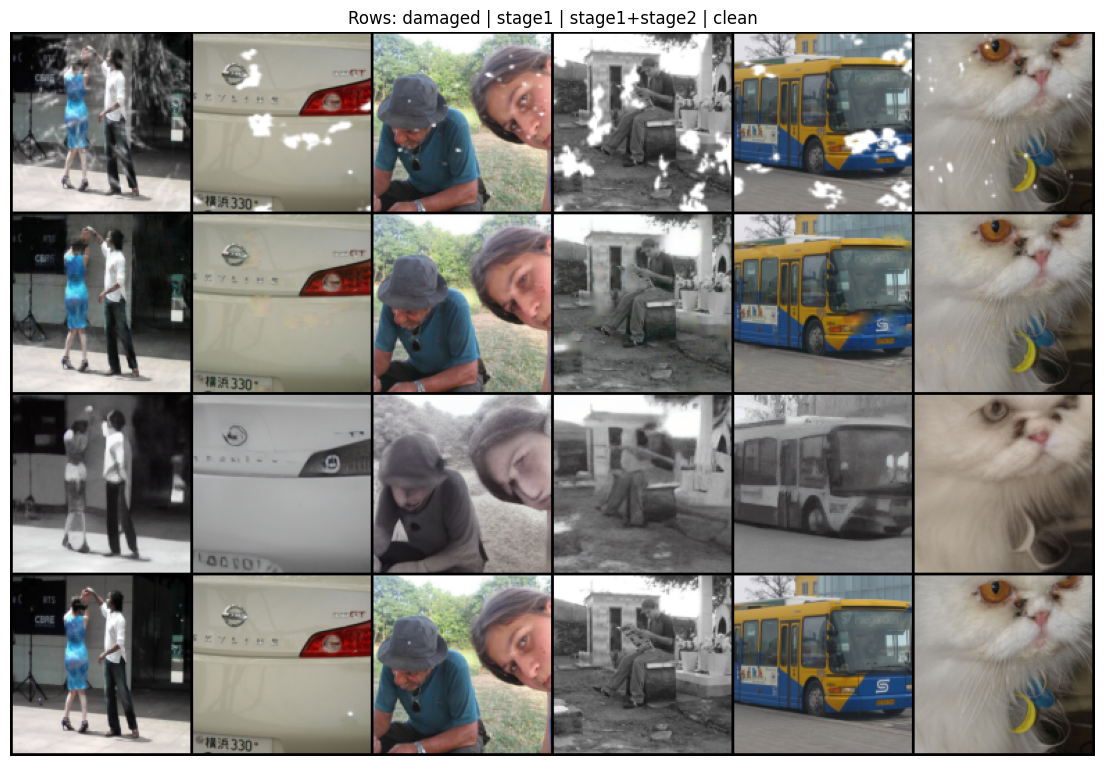

In [20]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('eval_results_stage2/comparison_grid.png')
plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis('off')
plt.title('Rows: damaged | stage1 | stage1+stage2 | clean')
plt.show()

In [21]:
import pandas as pd
df_stage1 = pd.read_csv('eval_results_stage1/metrics.csv')
print('--- Stage 1 alone ---')
print(df_stage1.describe())
df_stage2 = pd.read_csv('eval_results_stage2/metrics.csv')
print('--- Stage 1 + Stage 2 ---')
print(df_stage2.describe())

--- Stage 1 alone ---
       sample_index  damaged_psnr  damaged_ssim  damaged_lpips  restored_psnr  \
count     20.000000     20.000000     20.000000      20.000000      20.000000   
mean    8786.350000     23.468945      0.847775       0.144040      31.388440   
std     4722.680876      5.187767      0.101679       0.106207       2.360361   
min      151.000000     11.575500      0.619300       0.031100      27.247000   
25%     5951.750000     22.130800      0.780675       0.081950      29.966075   
50%     8652.000000     24.456650      0.898400       0.099400      31.002250   
75%    13081.250000     26.535500      0.922700       0.196350      31.798800   
max    16209.000000     30.503000      0.958500       0.457400      36.536700   

       restored_ssim  restored_lpips  
count      20.000000       20.000000  
mean        0.939180        0.032180  
std         0.032809        0.024283  
min         0.868400        0.006200  
25%         0.914375        0.017075  
50%         0.

In [22]:
import shutil

for folder in ['/kaggle/working/voc_data']:
    if os.path.isdir(folder):
        shutil.rmtree(folder)
        print(f'Deleted: {folder}')
    else:
        print(f'Not found (already clean): {folder}')

Deleted: /kaggle/working/voc_data
